## Imports

In [51]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import kagglehub
from kagglehub.datasets import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

## Load Dataset

In [52]:
file_path = 'housing_price_dataset.csv'

df = pd.read_csv('./Dataset/housing_price_dataset.csv')

df.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.2836
1,2459,3,2,Rural,1980,195014.2216
2,1860,2,1,Suburb,1970,306891.0121
3,2294,2,1,Urban,1996,206786.7872
4,2130,5,2,Suburb,2001,272436.2391


## Prepare Data

In [53]:
X = df[['SquareFeet', 'Bedrooms', 'Bathrooms', 'Neighborhood', 'YearBuilt']]
y = df['Price'].values.reshape(-1, 1)

X.shape, y.shape

((50000, 5), (50000, 1))

## EDA

In [54]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   SquareFeet    50000 non-null  int64 
 1   Bedrooms      50000 non-null  int64 
 2   Bathrooms     50000 non-null  int64 
 3   Neighborhood  50000 non-null  object
 4   YearBuilt     50000 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 1.9+ MB


In [55]:
X.describe()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420
std,575.513241,1.116326,0.815851,20.719377
min,1000.000000,2.000000,1.000000,1950.000000
25%,1513.000000,3.000000,1.000000,1967.000000
50%,2007.000000,3.000000,2.000000,1985.000000
75%,2506.000000,4.000000,3.000000,2003.000000
max,2999.000000,5.000000,3.000000,2021.000000


In [56]:
X.value_counts

<bound method DataFrame.value_counts of        SquareFeet  Bedrooms  Bathrooms Neighborhood  YearBuilt
0            2126         4          1        Rural       1969
1            2459         3          2        Rural       1980
2            1860         2          1       Suburb       1970
3            2294         2          1        Urban       1996
4            2130         5          2       Suburb       2001
...           ...       ...        ...          ...        ...
49995        1282         5          3        Rural       1975
49996        2854         2          2       Suburb       1988
49997        2979         5          3       Suburb       1962
49998        2596         5          2        Rural       1984
49999        1572         5          3        Rural       2011

[50000 rows x 5 columns]>

In [57]:
X.isnull().sum()

SquareFeet      0
Bedrooms        0
Bathrooms       0
Neighborhood    0
YearBuilt       0
dtype: int64

array([[<Axes: title={'center': 'SquareFeet'}>,
        <Axes: title={'center': 'Bedrooms'}>],
       [<Axes: title={'center': 'Bathrooms'}>,
        <Axes: title={'center': 'YearBuilt'}>]], dtype=object)

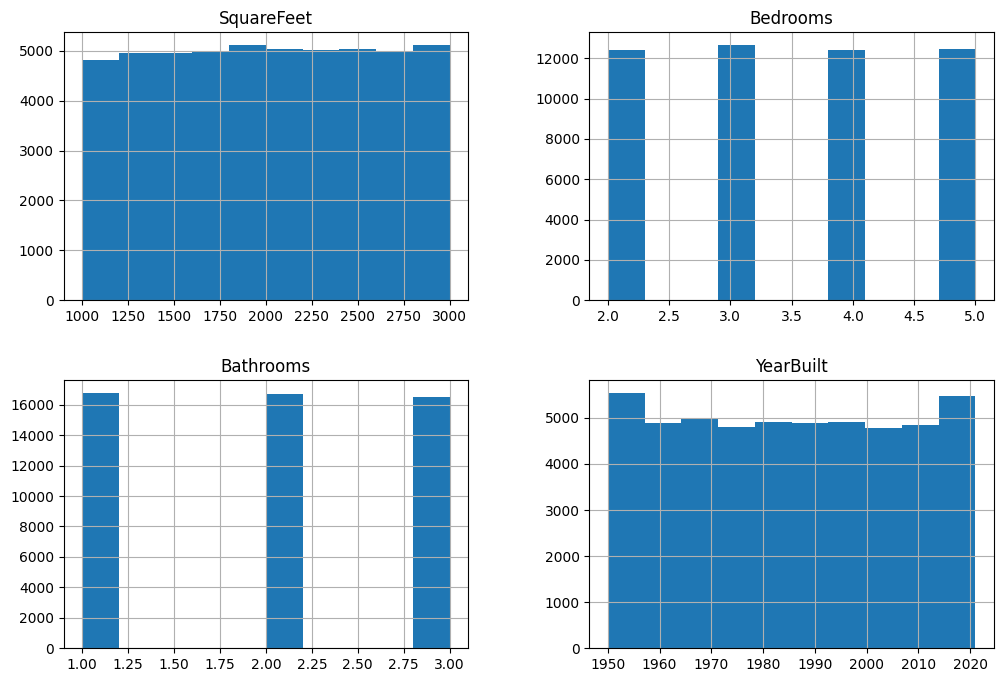

In [58]:
num_cols = ['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt']
X[num_cols].hist(bins = 10, figsize=(12, 8))

Text(0.5, 1.0, 'Price Distribution')

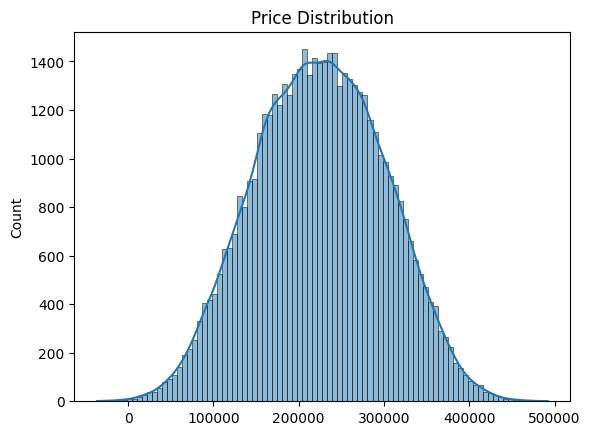

In [59]:
sns.histplot(y.flatten(), kde=True)
plt.title("Price Distribution")

In [60]:
# plt.figure(figsize = (12, 6))
# sns.boxenplot(data=X, x = 'Neighborhood', y='Price')
# plt.xticks(rotation = 45)
# plt.title("Price by Neighborhood")

Text(0.5, 1.0, 'Correlation Matrix')

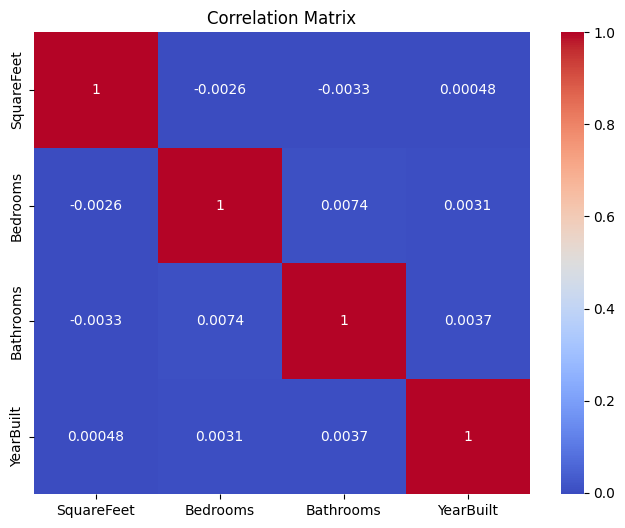

In [61]:
plt.figure(figsize=(8, 6))
sns.heatmap(X[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")

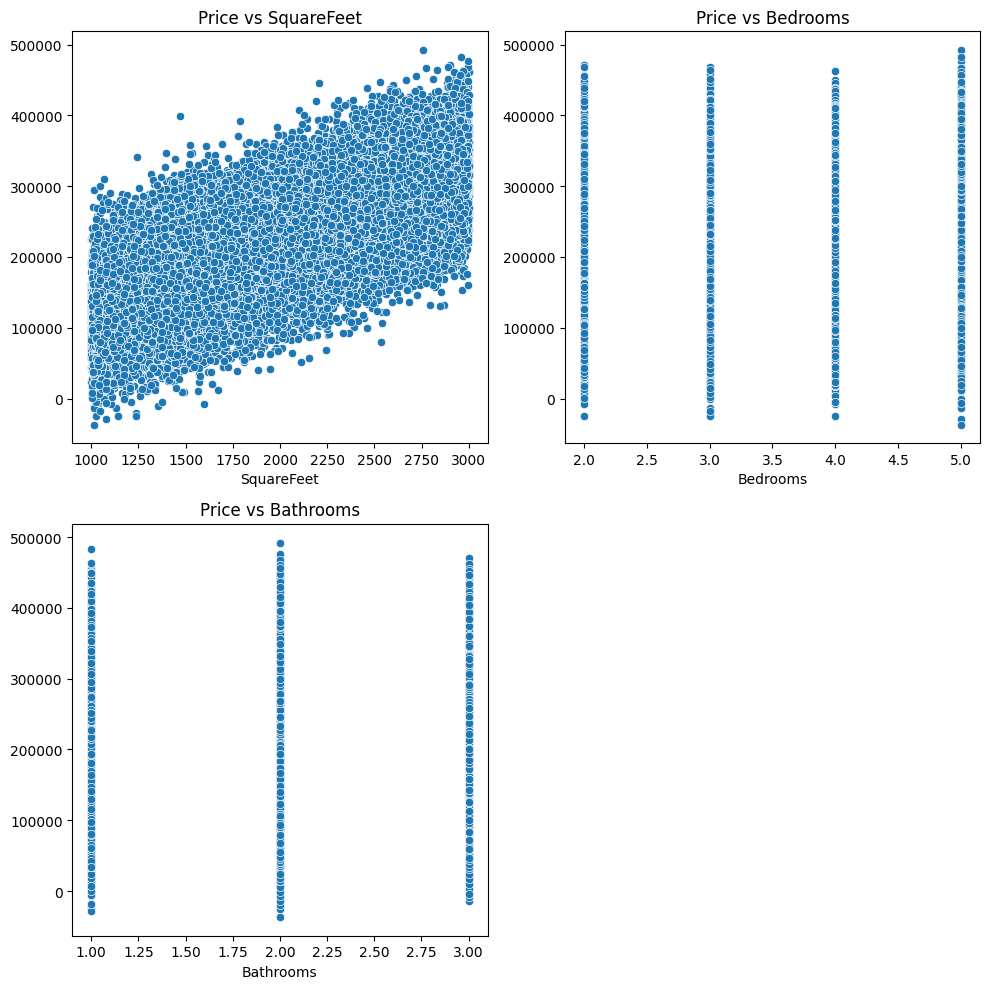

In [62]:
plt.figure(figsize=(10, 10))
for i, col in enumerate(num_cols[:-1]):
    plt.subplot(2,2, i + 1)
    sns.scatterplot(x=X[col], y = y.flatten())
    plt.title(f'Price vs {col}')
    plt.tight_layout()

## Category Encoding

In [63]:
X = pd.get_dummies(X, columns=['Neighborhood'], drop_first=True)
X.head()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Neighborhood_Suburb,Neighborhood_Urban
0,2126,4,1,1969,False,False
1,2459,3,2,1980,False,False
2,1860,2,1,1970,True,False
3,2294,2,1,1996,False,True
4,2130,5,2,2001,True,False


## Train test split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=25
)

X_train.shape, X_test.shape

((40000, 6), (10000, 6))

## Initialize and Train the model

In [65]:
model = LinearRegression()
model.fit(X=X_train, y=y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [66]:
predictions = model.predict(X=X_test)
predictions[:5, :]

array([[251943.57955065],
       [227010.69384634],
       [166069.36490827],
       [317480.50934008],
       [285156.10837435]])

In [67]:
mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
print(f"MAE: {mae}")
print(f"MAPE: {mape}")
print(f"RMSE: {rmse}")


MAE: 39581.468302641944
MAPE: 0.3163634383415354
RMSE: 49634.58593100794


## Visualizations

In [68]:
X_test.shape, y_test.shape, predictions.shape

((10000, 6), (10000, 1), (10000, 1))

(10000,)


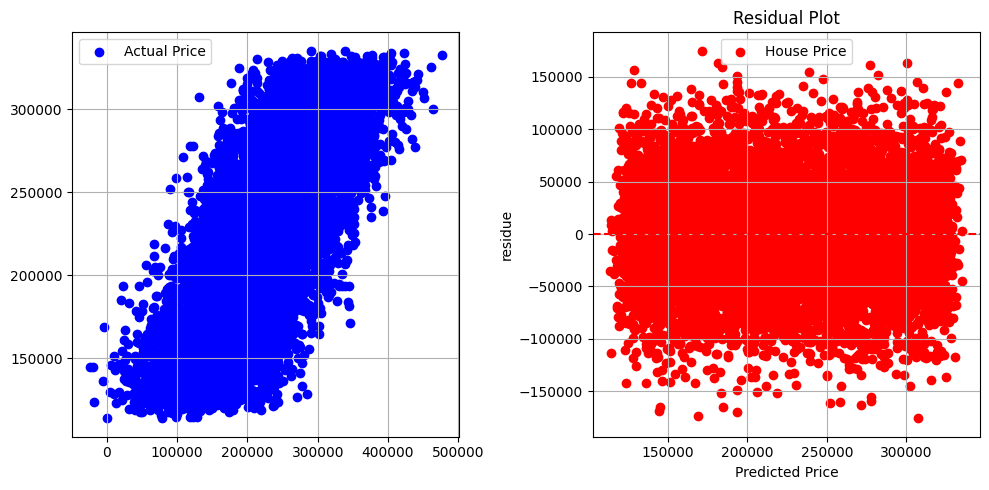

In [69]:
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.scatter(x=y_test, y=predictions, color='blue', label='Actual Price')
plt.legend()
plt.tight_layout()
plt.grid(True)

residue = y_test.flatten() - predictions.flatten()
print(residue.shape)
plt.subplot(1, 2, 2)
plt.scatter(x=predictions, y=residue, color='red', label='House Price')
plt.axhline(y=0, color='r', linestyle = '--')
plt.xlabel("Predicted Price")
plt.ylabel("residue")
plt.title("Residual Plot")
plt.legend()
plt.tight_layout()
plt.grid(True)

In [70]:
X_test

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Neighborhood_Suburb,Neighborhood_Urban
13920,2191,5,2,2021,False,True
23439,1968,5,1,2018,False,True
11851,1325,5,2,2003,False,True
8278,2976,3,2,2003,True,False
31258,2726,2,1,1961,True,False
...,...,...,...,...,...,...
39883,1786,3,2,1981,False,False
40521,1488,3,3,2008,False,True
19434,1472,5,2,1977,False,False
4571,2401,5,2,1994,False,False


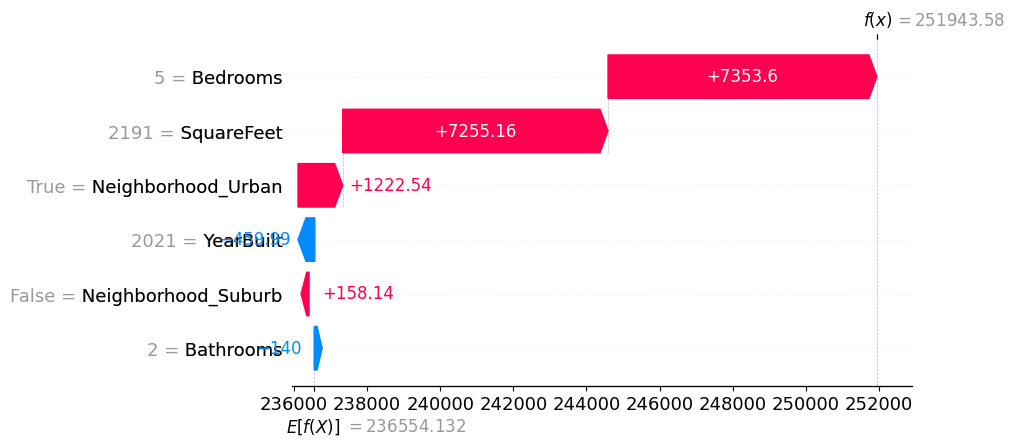

In [71]:
import shap
import matplotlib.pyplot as plt

shap.initjs()

explainer = shap.Explainer(model, X_test)

# Compute SHAP values
shap_values = explainer(X_test)

# Visualize (e.g., for one sample)
shap.plots.waterfall(shap_values[0])